In [1]:
# Esta celda define los parámetros globales y las funciones esenciales:
# - `physpoint`: wrapper para obtener los resultados del modelo
# - `loss`: métrica heurística (magnitud de los lambdas) para guiar la búsqueda

from lib.oracle import run_oracle, safe_run_oracle
from lib.utils import estimate_exploration_time, expand_parameter_space
import numpy as np
import matplotlib.pyplot as plt

# Parámetros globales del modelo
lambda6 = 0.1
lambda7 = 0.0
alpha = 1e-7
beta  = 1.570796226794897

def physpoint(mphi: float, m12_2: float, mA: float = 300.0):
    # Llama al modelo con valores fijos y retorna el diccionario de resultados
    return safe_run_oracle([mphi, mA, alpha, beta, lambda6, lambda7, m12_2])

def loss(mphi: float, m12_2: float, mA: float = 300.0):
    # Calcula una métrica basada en la suma de |lambda_i|
    output = physpoint(mphi, m12_2, mA)
    if output is None:
        return 1e10  # Penalización para errores o puntos no físicos
    return sum(np.abs(output[f'lambda{i}']) for i in range(1,6))

# Define función para verificar validez física del modelo
def is_valid(output: dict) -> bool:
    if output is None:
        return False
    return (
        output.get('positivity_ok', 0) == 1 and
        output.get('unitarity_ok', 0) == 1 and
        output.get('perturbativity_ok', 0) == 1
    )


In [3]:
# prueba corta de paralelsimo
import subprocess
import time
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed

# --------------------------------------
# 2) Genera un conjunto de inputs dummy
# --------------------------------------
# Por ejemplo 20 pares (mphi, m12)
inputs = [(125 + i*10, -0.1 + i*0.01) for i in range(20)]


# --------------------------------------------------
# 3) Medición secuencial para referencia
# --------------------------------------------------
t0 = time.time()
seq_results = [loss(m, x) for m, x in inputs]
t_seq = time.time() - t0
print(f"Secuencial: {t_seq:.2f} s")


# --------------------------------------------------
# 4) Medición con hilos (ThreadPoolExecutor)
# --------------------------------------------------
n_threads = 4
t0 = time.time()
with ThreadPoolExecutor(max_workers=n_threads) as exe:
    seq_fut = [exe.submit(loss, m, x) for m, x in inputs]
    thr_results = [f.result() for f in as_completed(seq_fut)]
t_thr = time.time() - t0
print(f"Multithreading ({n_threads} hilos): {t_thr:.2f} s")


# --------------------------------------------------
# 5) Medición con procesos (ProcessPoolExecutor)
# --------------------------------------------------
n_procs = 4
t0 = time.time()
with ProcessPoolExecutor(max_workers=n_procs) as exe:
    proc_fut = [exe.submit(loss, m, x) for m, x in inputs]
    proc_results = [f.result() for f in as_completed(proc_fut)]
t_proc = time.time() - t0
print(f"Multiprocessing ({n_procs} procesos): {t_proc:.2f} s")


# --------------------------------------------------
# 6) Resumen
# --------------------------------------------------
print()
print("Resumen de tiempos:")
print(f"- Secuencial        : {t_seq:.2f} s")
print(f"- Hilos ({n_threads})   : {t_thr:.2f} s  → x{t_seq/t_thr:.1f} speed-up")
print(f"- Procesos ({n_procs}) : {t_proc:.2f} s  → x{t_seq/t_proc:.1f} speed-up")

Secuencial: 0.01 s
Multithreading (4 hilos): 0.03 s
Multiprocessing (4 procesos): 0.09 s

Resumen de tiempos:
- Secuencial        : 0.01 s
- Hilos (4)   : 0.03 s  → x0.5 speed-up
- Procesos (4) : 0.09 s  → x0.2 speed-up


In [4]:
# Exploración sistemática de (mphi, m12) en una grilla
def explore_dense(mphi_range, m12_range, mA=300.0, max_loss=50):
    valid_points = []
    tested_points = []

    for mphi in mphi_range:
        for m12 in m12_range:
            out = physpoint(mphi, m12, mA)
            l = loss(mphi, m12, mA)
            tested_points.append((mphi, m12, l))

            if out is not None and l < max_loss and is_valid(out):
                valid_points.append({
                    'mphi': mphi,
                    'm12': m12,
                    'mA': mA,
                    'loss': l,
                    'output': out
                })

    return valid_points, tested_points


In [ ]:
def plot_exploration(valid_points, tested_points):
    import matplotlib.pyplot as plt

    # Separar datos
    all_mphi, all_m12, all_loss = zip(*tested_points)
    valid_mphi = [p['mphi'] for p in valid_points]
    valid_m12  = [p['m12'] for p in valid_points]

    fig, ax = plt.subplots(figsize=(8,6))
    sc = ax.scatter(all_mphi, all_m12, c=np.log10(all_loss), cmap='viridis', s=15)
    ax.scatter(valid_mphi, valid_m12, c='red', s=30, edgecolors='k', label='✓ físicos')

    ax.set_xlabel(r'$m_\phi$ [GeV]')
    ax.set_ylabel(r'$m_{12}$')
    ax.set_title(r'$\log_{10}$(loss) y puntos válidos')
    fig.colorbar(sc, label='log10(loss)')
    ax.legend()
    plt.show()


def plot_optimization_results(opt_result):
    X = np.array(opt_result.x_iters)
    y = np.array(opt_result.func_vals)

    fig, ax = plt.subplots(figsize=(8,6))
    sc = ax.scatter(X[:,0], X[:,1], c=np.log10(y), cmap='plasma', s=30)
    ax.set_xlabel(r'$m_\phi$')
    ax.set_ylabel(r'$m_{12}$')
    ax.set_title('Bayesian search: log10(loss)')
    fig.colorbar(sc, label='log10(loss)')
    plt.show()


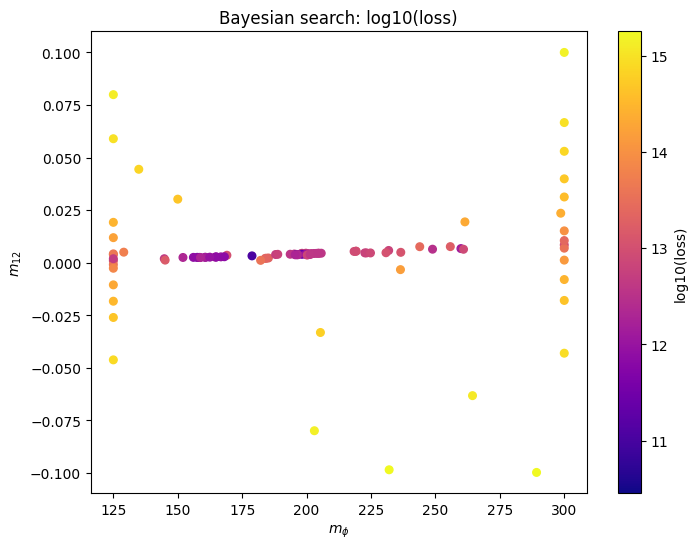

In [13]:
# Si aún no lo tienes, instala con: pip install scikit-optimize
from skopt import gp_minimize
from skopt.space import Real

search_space = [
    Real(125.0, 300.0, name='mphi'),
    Real(-0.1,  0.1,   name='m12')
]

def loss_wrapper(params):
    mphi, m12 = params
    return loss(mphi, m12)

# Ejecutar optimización bayesiana (puedes aumentar n_calls)
opt_result = gp_minimize(loss_wrapper, search_space, n_calls=100, random_state=42)


plot_optimization_results(opt_result)

In [14]:
from joblib import dump

# Guarda tu resultado para futuras sesiones
dump(opt_result, "opt_result_initial.pkl")


['opt_result_initial.pkl']

In [ ]:
from joblib import load

# Cargar el resultado guardado
opt_result = load("opt_result_initial.pkl")


In [ ]:
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args

# Tu espacio de búsqueda original
search_space = [
    Real(125.0, 300.0, name='mphi'),
    Real(-0.1,  0.1,   name='m12')
]

# Tu función original
@use_named_args(search_space)
def loss_named(mphi, m12):
    return loss(mphi, m12)

# Continuar desde resultados anteriores
opt_result_extended = gp_minimize(
    loss_named,
    search_space,
    n_calls=300,  
    x0=opt_result.x_iters,  # puntos anteriores
    y0=opt_result.func_vals,
    random_state=42
)


KeyboardInterrupt: 

In [16]:
plot_optimization_results(opt_result_extended)
dump(opt_result_extended, "opt_result_extended.pkl")


NameError: name 'opt_result_extended' is not defined

In [ ]:

import pandas as pd

def save_valid_points(valid_points, filename="valid_points.csv"):
    flat_data = [{
        'mphi': p['mphi'],
        'm12': p['m12'],
        'mA': p['mA'],
        'loss': p['loss'],
        'br_h2_gaga': p['output'].get('branching_ratio_h2_gaga', None),
        'lambda1': p['output'].get('lambda1'),
        'lambda2': p['output'].get('lambda2'),
        'lambda3': p['output'].get('lambda3'),
        'lambda4': p['output'].get('lambda4'),
        'lambda5': p['output'].get('lambda5'),
    } for p in valid_points]
    df = pd.DataFrame(flat_data)
    df.to_csv(filename, index=False)


# Exploracion Sistematica

In [ ]:
def evaluate_point(mphi, m12, mA=300.0):
    out = physpoint(mphi, m12, mA)
    if out is None:
        return None
    
    result = {
        'mphi': mphi,
        'm12': m12,
        'mA': mA,
        'loss': loss(mphi, m12, mA),
        'valid': is_valid(out),
        'output': out
    }
    return result

In [ ]:



def auto_zoom(valid_points, factor=0.25, npts=20):
    """Genera nueva grilla local en torno a puntos válidos"""
    mphi_vals = []
    m12_vals  = []

    for p in valid_points:
        mphi = np.linspace(p['mphi']*(1-factor), p['mphi']*(1+factor), npts)
        m12  = np.linspace(p['m12'] - factor, p['m12'] + factor, npts)
        mphi_vals.extend(mphi)
        m12_vals.extend(m12)

    # Eliminar duplicados
    return list(set(mphi_vals)), list(set(m12_vals))


def run_adaptive_search(initial_mphi, initial_m12, max_loops=3, min_valid=3):
    mphi_range = initial_mphi
    m12_range  = initial_m12
    all_valid  = []

    for step in range(max_loops):
        print(f"🔍 Explorando nivel {step}...")
        valids, tested = explore_dense(mphi_range, m12_range)

        print(f"  ↪ Se encontraron {len(valids)} puntos válidos")

        all_valid.extend(valids)

        if len(valids) < min_valid:
            print("  ⚠️ Muy pocos puntos válidos — expandiendo búsqueda")
            mphi_range = np.linspace(min(initial_mphi), max(initial_mphi), len(mphi_range) + 10)
            m12_range  = np.linspace(min(initial_m12), max(initial_m12), len(m12_range) + 10)
        else:
            mphi_range, m12_range = auto_zoom(valids)

    return all_valid
